In [1]:
# Import library for cryptocompare data.
import cryptocompare

# Import data manipulation library.
import pandas as pd
import numpy as np

# Import date and time library.
import datetime

# Import plotting library.
import matplotlib.pyplot as plt

In [3]:
# Set the API key.

key = "insert key here"

cryptocompare.cryptocompare._set_api_key_parameter(key)

'&api_key=93976635120a15401044e2341cde76f6d389ede507109e7cf473c350ddde833d'

In [2]:
# Define the list of coins.

coins = ["BTC", "ETH", "BNB", "SOL", "XRP", "ADA", "AVAX", "DOT", "LINK", "TRX", "MATIC", "LTC", "UNI", "FET", "NEAR"]

In [31]:
# Define a function that will repetedly call for data until a certain date is reached. Only 2000 rows can be downloaded at a time.

def get_data(token):

    data = pd.DataFrame(cryptocompare.get_historical_price_day(token, "USD", exchange="CCCAGG", toTs=datetime.datetime(2024, 4, 1, 0, 0)))[["close", "time"]]
    data.rename(columns = {'close':token}, inplace = True)
    data.rename(columns = {'time':'Date'}, inplace = True)
    data.set_index("Date", inplace=True)
    data.index = pd.to_datetime(data.index, unit="s").date
    
    while True:

        if data.index[0] < datetime.datetime(2014, 4, 1, 0, 0).date():
            break

        df = pd.DataFrame(cryptocompare.get_historical_price_day(token, "USD", exchange="CCCAGG", toTs=data.index[0]))[["close", "time"]]
        df.rename(columns = {'close':token}, inplace = True)
        df.rename(columns = {'time':'Date'}, inplace = True)
        df.set_index("Date", inplace=True)
        df.index = pd.to_datetime(df.index, unit="s").date

        data = pd.concat([df, data])
        
    return data.loc[data.index >= datetime.datetime(2014, 4, 1, 0, 0).date(), :]






In [32]:
# Download data for BTC separately so that other coins can be added to it in the loop.

main = get_data("BTC")

In [36]:
# Add other coins.

for coin in coins:
    if coin == "BTC":
        continue
    else:
        df = get_data(coin)
        main = pd.merge(main, df, left_index=True, right_index=True, how='outer')



In [38]:
main.to_excel("check.xlsx")

In [100]:
################# DAILY DATA #################

In [3]:
# Import data.

daily = pd.read_excel("check.xlsx")
daily.rename(columns = {'Unnamed: 0':'Date'}, inplace = True)
daily.index = daily["Date"]
daily = daily.drop("Date", axis=1)
daily = daily.loc["2019-04-30":]

In [4]:
# Get summary statistics

daily.describe().to_excel("summary_daily.xlsx")

In [5]:
# Get a set of arrays with cumulative products.

cprods_daily = {}

In [6]:
n = 5
for momentum in [2, 3, 5, 7, 10, 14, 21, 30]:

    # Get a fresh dataset of prices.
    df = daily.copy()    
    # Remove infnite returns.
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Remove prices equal to zero. This indicates that a coin was not traded, there are no periods where the price was the same for more than one day in the sample.
    df.replace(0, np.nan, inplace=True)
    # Compute momenta and returns.
    for c in coins:
        df[f"{c}_MOM_{momentum}"] = (df[c].shift(1)/df[c].shift(momentum)) - 1
        df[f"{c}_RET"] = (df[c]/df[c].shift(1)) - 1
    # Define new columns.
    df["High Portfolio Return"] = np.nan
    df["Low Portfolio Return"] = np.nan
    df["UMD Portfolio Return"] = np.nan
    # Find portfolios.
    for index, row in df.iterrows():
        if index < pd.to_datetime("2019-10-31"):
            continue
        compare = {}
        for c in df.columns:
            if "_MOM_" not in c:
                continue
            else:
                compare[c.replace(f"_MOM_{momentum}", "_RET")] = row[c]
        
        compare = {k: compare[k] for k in compare if not np.isnan(compare[k])}
        compare = dict(sorted(compare.items(), key=lambda item: item[1], reverse=True))
        
        df.at[index, "High Portfolio Return"] = row[list(compare.keys())[:n]].mean()
        df.at[index, "Low Portfolio Return"] =  row[list(compare.keys())[-n:]].mean()
        df.at[index, "UMD Portfolio Return"] =  row[list(compare.keys())[:n]].mean() - row[list(compare.keys())[-n:]].mean()
    
    # Compute annualized performance metrics of the High Momentum Portfolio.
    annualized_mean_h = df["High Portfolio Return"].mean() * 365
    annualized_std_h = df["High Portfolio Return"].std() * np.sqrt(365)
    sharpe_h = annualized_mean_h / annualized_std_h
    # Return results.
    print(f"Results for daily sampling and momentum look-back of {momentum} days:")
    print(f"Annualized Average Returns of the High Momentum Portfolio: {annualized_mean_h}.")
    print(f"Annualized standard deviation of the High Momentum Portfolio: {annualized_std_h}.")
    print(f"Sharpe ratio of the High Momentum Portfolio: {sharpe_h}.")
    # Compute annualized performance metrics of the Low Momentum Portfolio.
    annualized_mean_l = df["Low Portfolio Return"].mean() * 365
    annualized_std_l = df["Low Portfolio Return"].std() * np.sqrt(365)
    sharpe_l = annualized_mean_l / annualized_std_l
    # Return results.
    print(f"Annualized Average Returns of the Low Momentum Portfolio: {annualized_mean_l}.")
    print(f"Annualized standard deviation of the Low Momentum Portfolio: {annualized_std_l}.")
    print(f"Sharpe ratio of the Low Momentum Portfolio: {sharpe_l}.")
    # Compute annualized performance metrics of the UMD Momentum Portfolio.
    annualized_mean_umd = df["UMD Portfolio Return"].mean() * 365
    annualized_std_umd = df["UMD Portfolio Return"].std() * np.sqrt(365)
    sharpe_umd = annualized_mean_umd / annualized_std_umd
    # Return results.
    print(f"Annualized Average Returns of the UMD Momentum Portfolio: {annualized_mean_umd}.")
    print(f"Annualized standard deviation of the UMD Momentum Portfolio: {annualized_std_umd}.")
    print(f"Sharpe ratio of the UMD Momentum Portfolio: {sharpe_umd}.")



    cprods_daily[momentum] = (1 + df["High Portfolio Return"]).cumprod(skipna=True) 
    
    print("\n")






    

Results for daily sampling and momentum look-back of 2 days:
Annualized Average Returns of the High Momentum Portfolio: 1.2353820994177458.
Annualized standard deviation of the High Momentum Portfolio: 0.9052678016260114.
Sharpe ratio of the High Momentum Portfolio: 1.3646592723156554.
Annualized Average Returns of the Low Momentum Portfolio: 1.1707608288721878.
Annualized standard deviation of the Low Momentum Portfolio: 0.9272980525464114.
Sharpe ratio of the Low Momentum Portfolio: 1.262550725365177.
Annualized Average Returns of the UMD Momentum Portfolio: 0.06462127054555798.
Annualized standard deviation of the UMD Momentum Portfolio: 0.5675052100367755.
Sharpe ratio of the UMD Momentum Portfolio: 0.1138690348611432.


Results for daily sampling and momentum look-back of 3 days:
Annualized Average Returns of the High Momentum Portfolio: 1.4990787995863426.
Annualized standard deviation of the High Momentum Portfolio: 0.9003845125411818.
Sharpe ratio of the High Momentum Portfolio

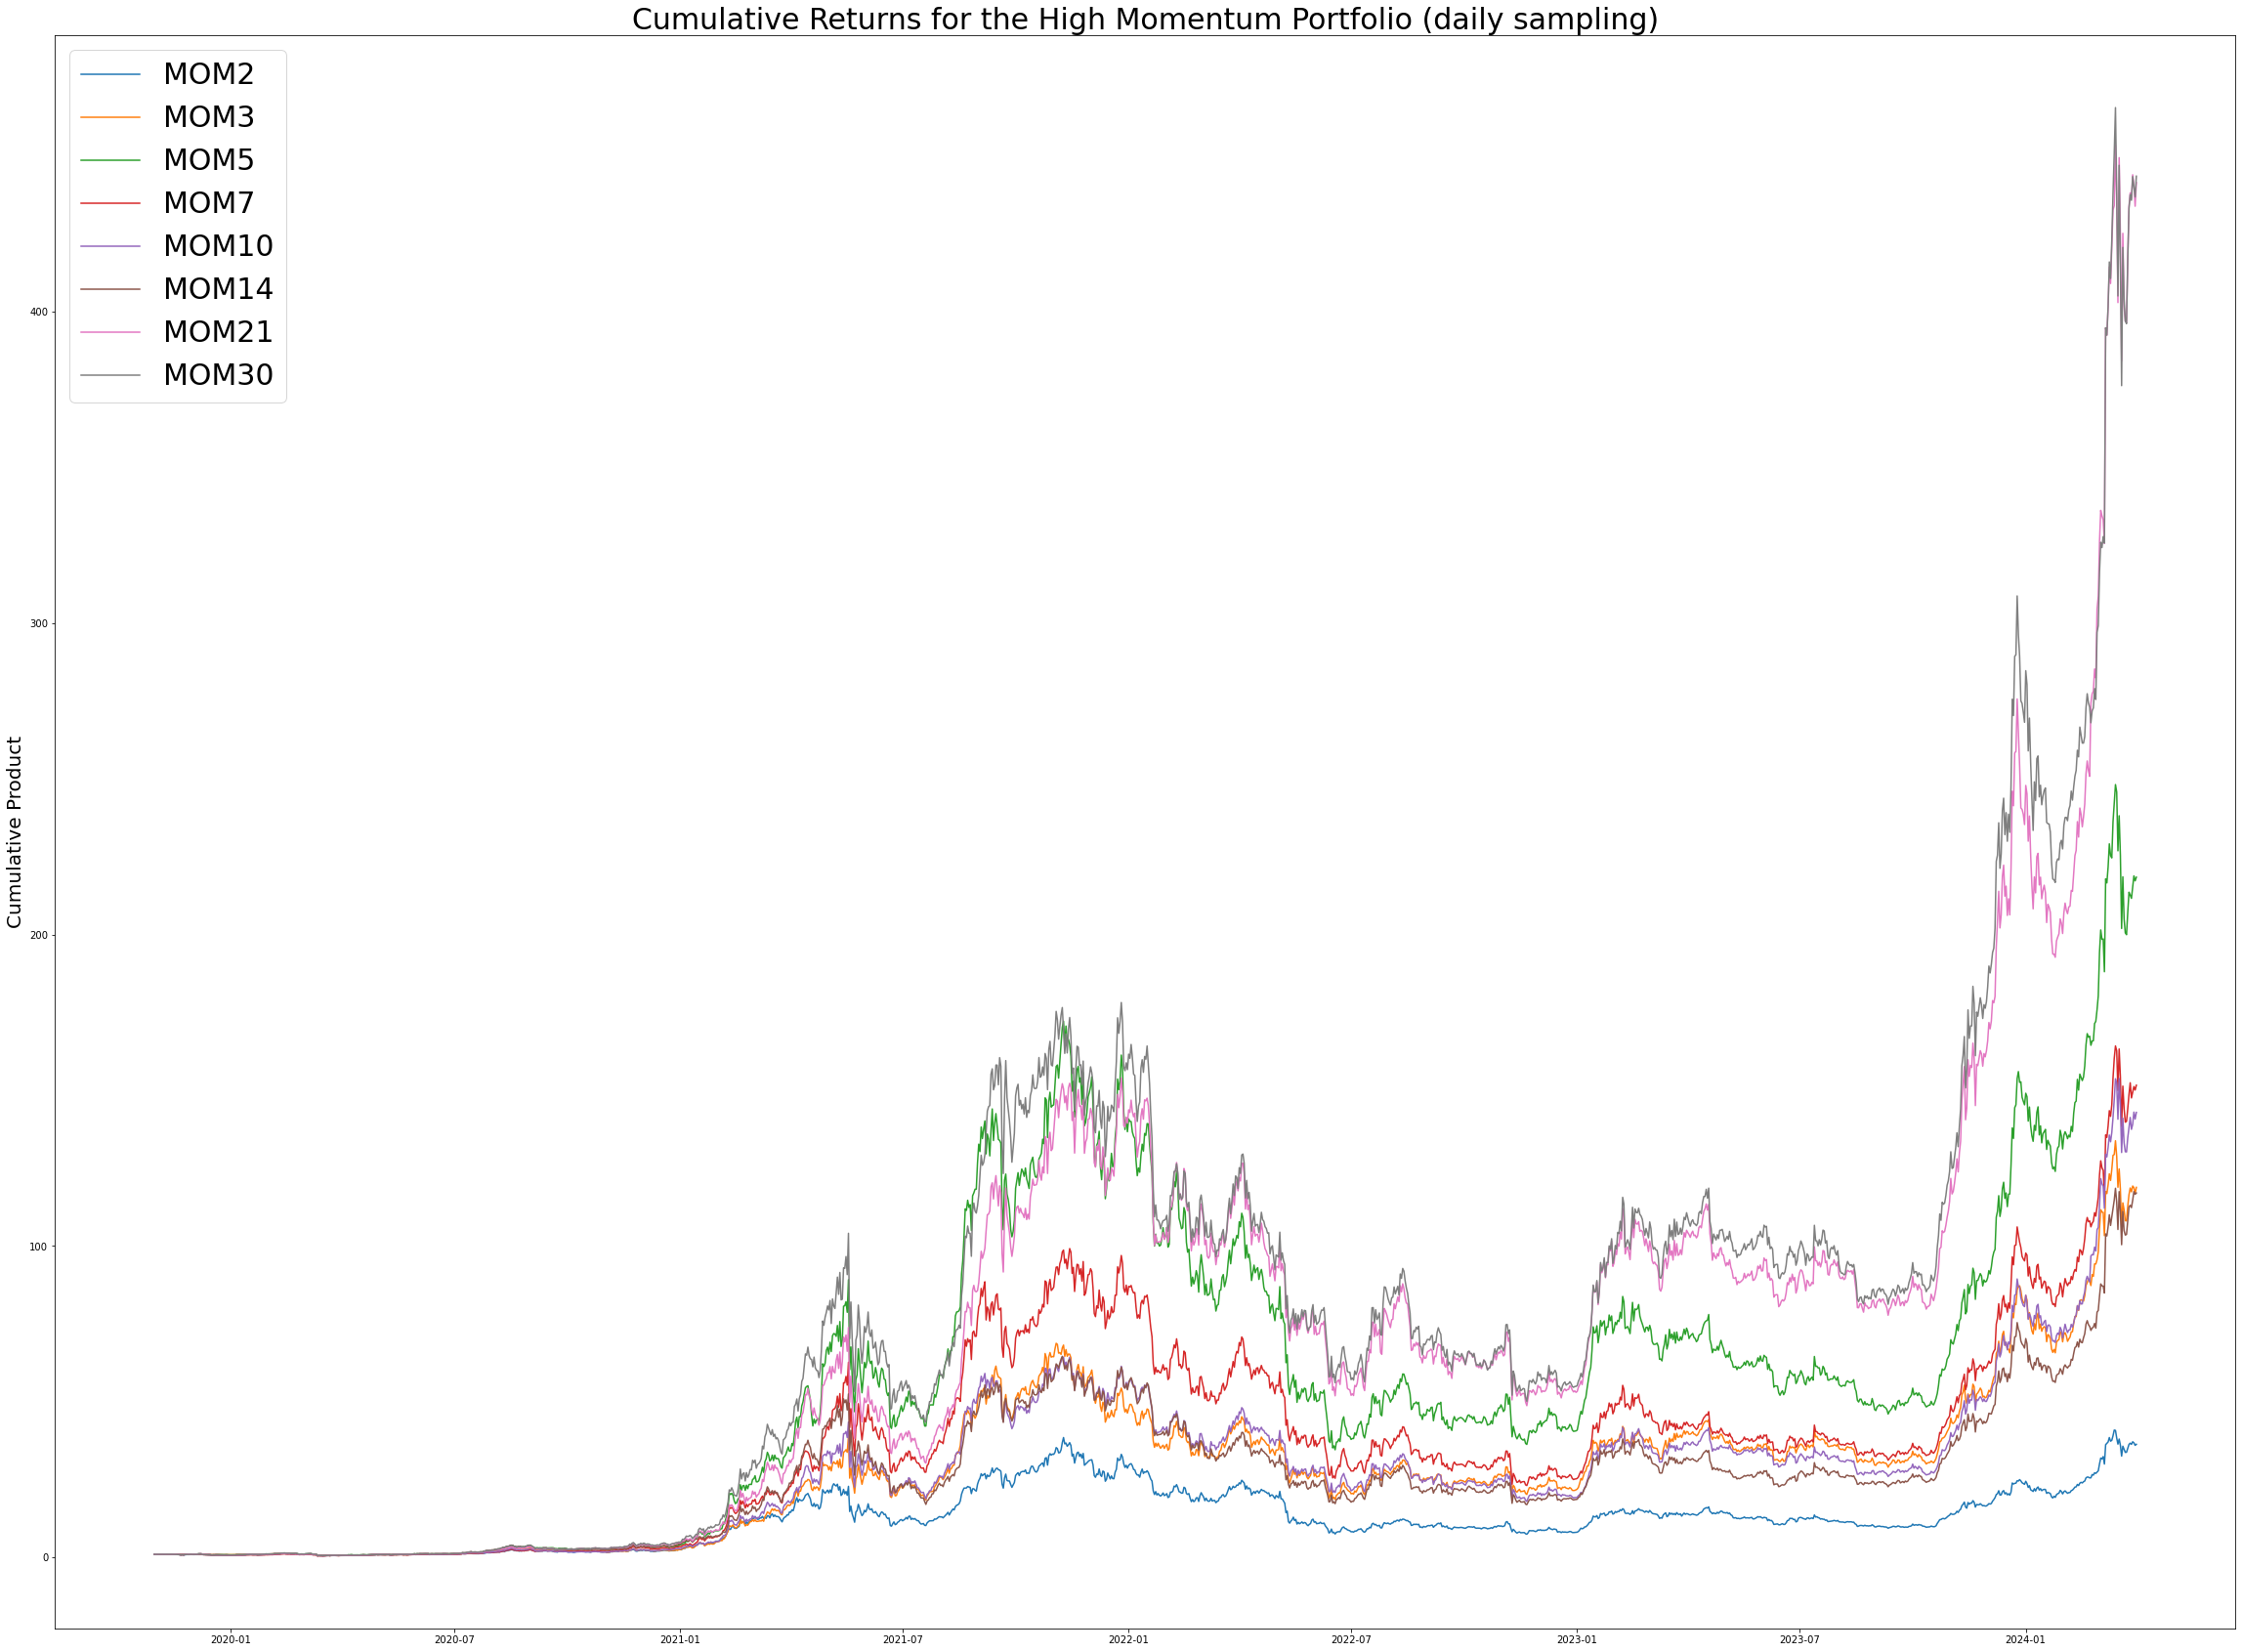

In [7]:
plt.figure(figsize=(40, 30))

for key in list(cprods_daily.keys()):
    plt.plot(cprods_daily[key])


plt.ylabel('Cumulative Product', fontsize=20)
plt.title('Cumulative Returns for the High Momentum Portfolio (daily sampling)', fontsize=30)
plt.legend(["MOM2", "MOM3", "MOM5", "MOM7", "MOM10", "MOM14", "MOM21", "MOM30"], loc='upper left', fontsize=30)
plt.savefig('plot_daily.png')
plt.show()


In [8]:
################# MONTHLY DATA #################

In [9]:
# Import and resample data.

monthly = pd.read_excel("check.xlsx")
monthly.rename(columns = {'Unnamed: 0':'Date'}, inplace = True) 
monthly.set_index(monthly['Date'], inplace=True)
monthly.drop('Date', axis=1, inplace=True)
monthly = monthly.resample('M').last()
monthly = monthly.loc["2019-04-30":]



In [10]:
# Get summary statistics

monthly.describe().to_excel("summary_monthly.xlsx")

In [11]:
# Get a set of arrays with cumulative products.

cprods_monthly = {}

In [12]:
n = 5
for momentum in [2, 3, 4, 6]:

    # Get a fresh dataset of prices.
    df = monthly.copy()    
    # Remove infnite returns.
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Remove prices equal to zero. This indicates that a coin was not traded, there are no periods where the price was the same for more than one day in the sample.
    df.replace(0, np.nan, inplace=True)
    # Compute momenta and returns.
    for c in coins:
        df[f"{c}_MOM_{momentum}"] = (df[c].shift(1)/df[c].shift(momentum)) - 1
        df[f"{c}_RET"] = (df[c]/df[c].shift(1)) - 1
    # Define new columns.
    df["High Portfolio Return"] = np.nan
    df["Low Portfolio Return"] = np.nan
    df["UMD Portfolio Return"] = np.nan
    # Find portfolios.
    for index, row in df.iterrows():
        if index < pd.to_datetime("2019-10-31"):
            continue
        compare = {}
        for c in df.columns:
            if "_MOM_" not in c:
                continue
            else:
                compare[c.replace(f"_MOM_{momentum}", "_RET")] = row[c]
        
        compare = {k: compare[k] for k in compare if not np.isnan(compare[k])}
        compare = dict(sorted(compare.items(), key=lambda item: item[1], reverse=True))
        
        df.at[index, "High Portfolio Return"] = row[list(compare.keys())[:n]].mean()
        df.at[index, "Low Portfolio Return"] =  row[list(compare.keys())[-n:]].mean()
        df.at[index, "UMD Portfolio Return"] =  row[list(compare.keys())[:n]].mean() - row[list(compare.keys())[-n:]].mean()
    
    # Compute annualized performance metrics of the High Momentum Portfolio.
    annualized_mean_h = df["High Portfolio Return"].mean() * 12
    annualized_std_h = df["High Portfolio Return"].std() * np.sqrt(12)
    sharpe_h = annualized_mean_h / annualized_std_h
    # Return results.
    print(f"Results for monthly sampling and momentum look-back of {momentum} months:")
    print(f"Annualized Average Returns of the High Momentum Portfolio: {annualized_mean_h}.")
    print(f"Annualized standard deviation of the High Momentum Portfolio: {annualized_std_h}.")
    print(f"Sharpe ratio of the High Momentum Portfolio: {sharpe_h}.")
    # Compute annualized performance metrics of the Low Momentum Portfolio.
    annualized_mean_l = df["Low Portfolio Return"].mean() * 12
    annualized_std_l = df["Low Portfolio Return"].std() * np.sqrt(12)
    sharpe_l = annualized_mean_l / annualized_std_l
    # Return results.
    print(f"Annualized Average Returns of the Low Momentum Portfolio: {annualized_mean_l}.")
    print(f"Annualized standard deviation of the Low Momentum Portfolio: {annualized_std_l}.")
    print(f"Sharpe ratio of the Low Momentum Portfolio: {sharpe_l}.")
    # Compute annualized performance metrics of the UMD Momentum Portfolio.
    annualized_mean_umd = df["UMD Portfolio Return"].mean() * 12
    annualized_std_umd = df["UMD Portfolio Return"].std() * np.sqrt(12)
    sharpe_umd = annualized_mean_umd / annualized_std_umd
    # Return results.
    print(f"Annualized Average Returns of the UMD Momentum Portfolio: {annualized_mean_umd}.")
    print(f"Annualized standard deviation of the UMD Momentum Portfolio: {annualized_std_umd}.")
    print(f"Sharpe ratio of the UMD Momentum Portfolio: {sharpe_umd}.")

    cprods_monthly[momentum] = (1 + df["High Portfolio Return"]).cumprod(skipna=True) 
    
    print("\n")

Results for monthly sampling and momentum look-back of 2 months:
Annualized Average Returns of the High Momentum Portfolio: 1.898856432962032.
Annualized standard deviation of the High Momentum Portfolio: 1.3276408581044299.
Sharpe ratio of the High Momentum Portfolio: 1.430248565619748.
Annualized Average Returns of the Low Momentum Portfolio: 1.0769469041385515.
Annualized standard deviation of the Low Momentum Portfolio: 1.174336777132577.
Sharpe ratio of the Low Momentum Portfolio: 0.9170681912629646.
Annualized Average Returns of the UMD Momentum Portfolio: 0.8219095288234803.
Annualized standard deviation of the UMD Momentum Portfolio: 0.7801514156647973.
Sharpe ratio of the UMD Momentum Portfolio: 1.05352565196988.


Results for monthly sampling and momentum look-back of 3 months:
Annualized Average Returns of the High Momentum Portfolio: 1.5890726800753856.
Annualized standard deviation of the High Momentum Portfolio: 1.120678177189873.
Sharpe ratio of the High Momentum Portfol

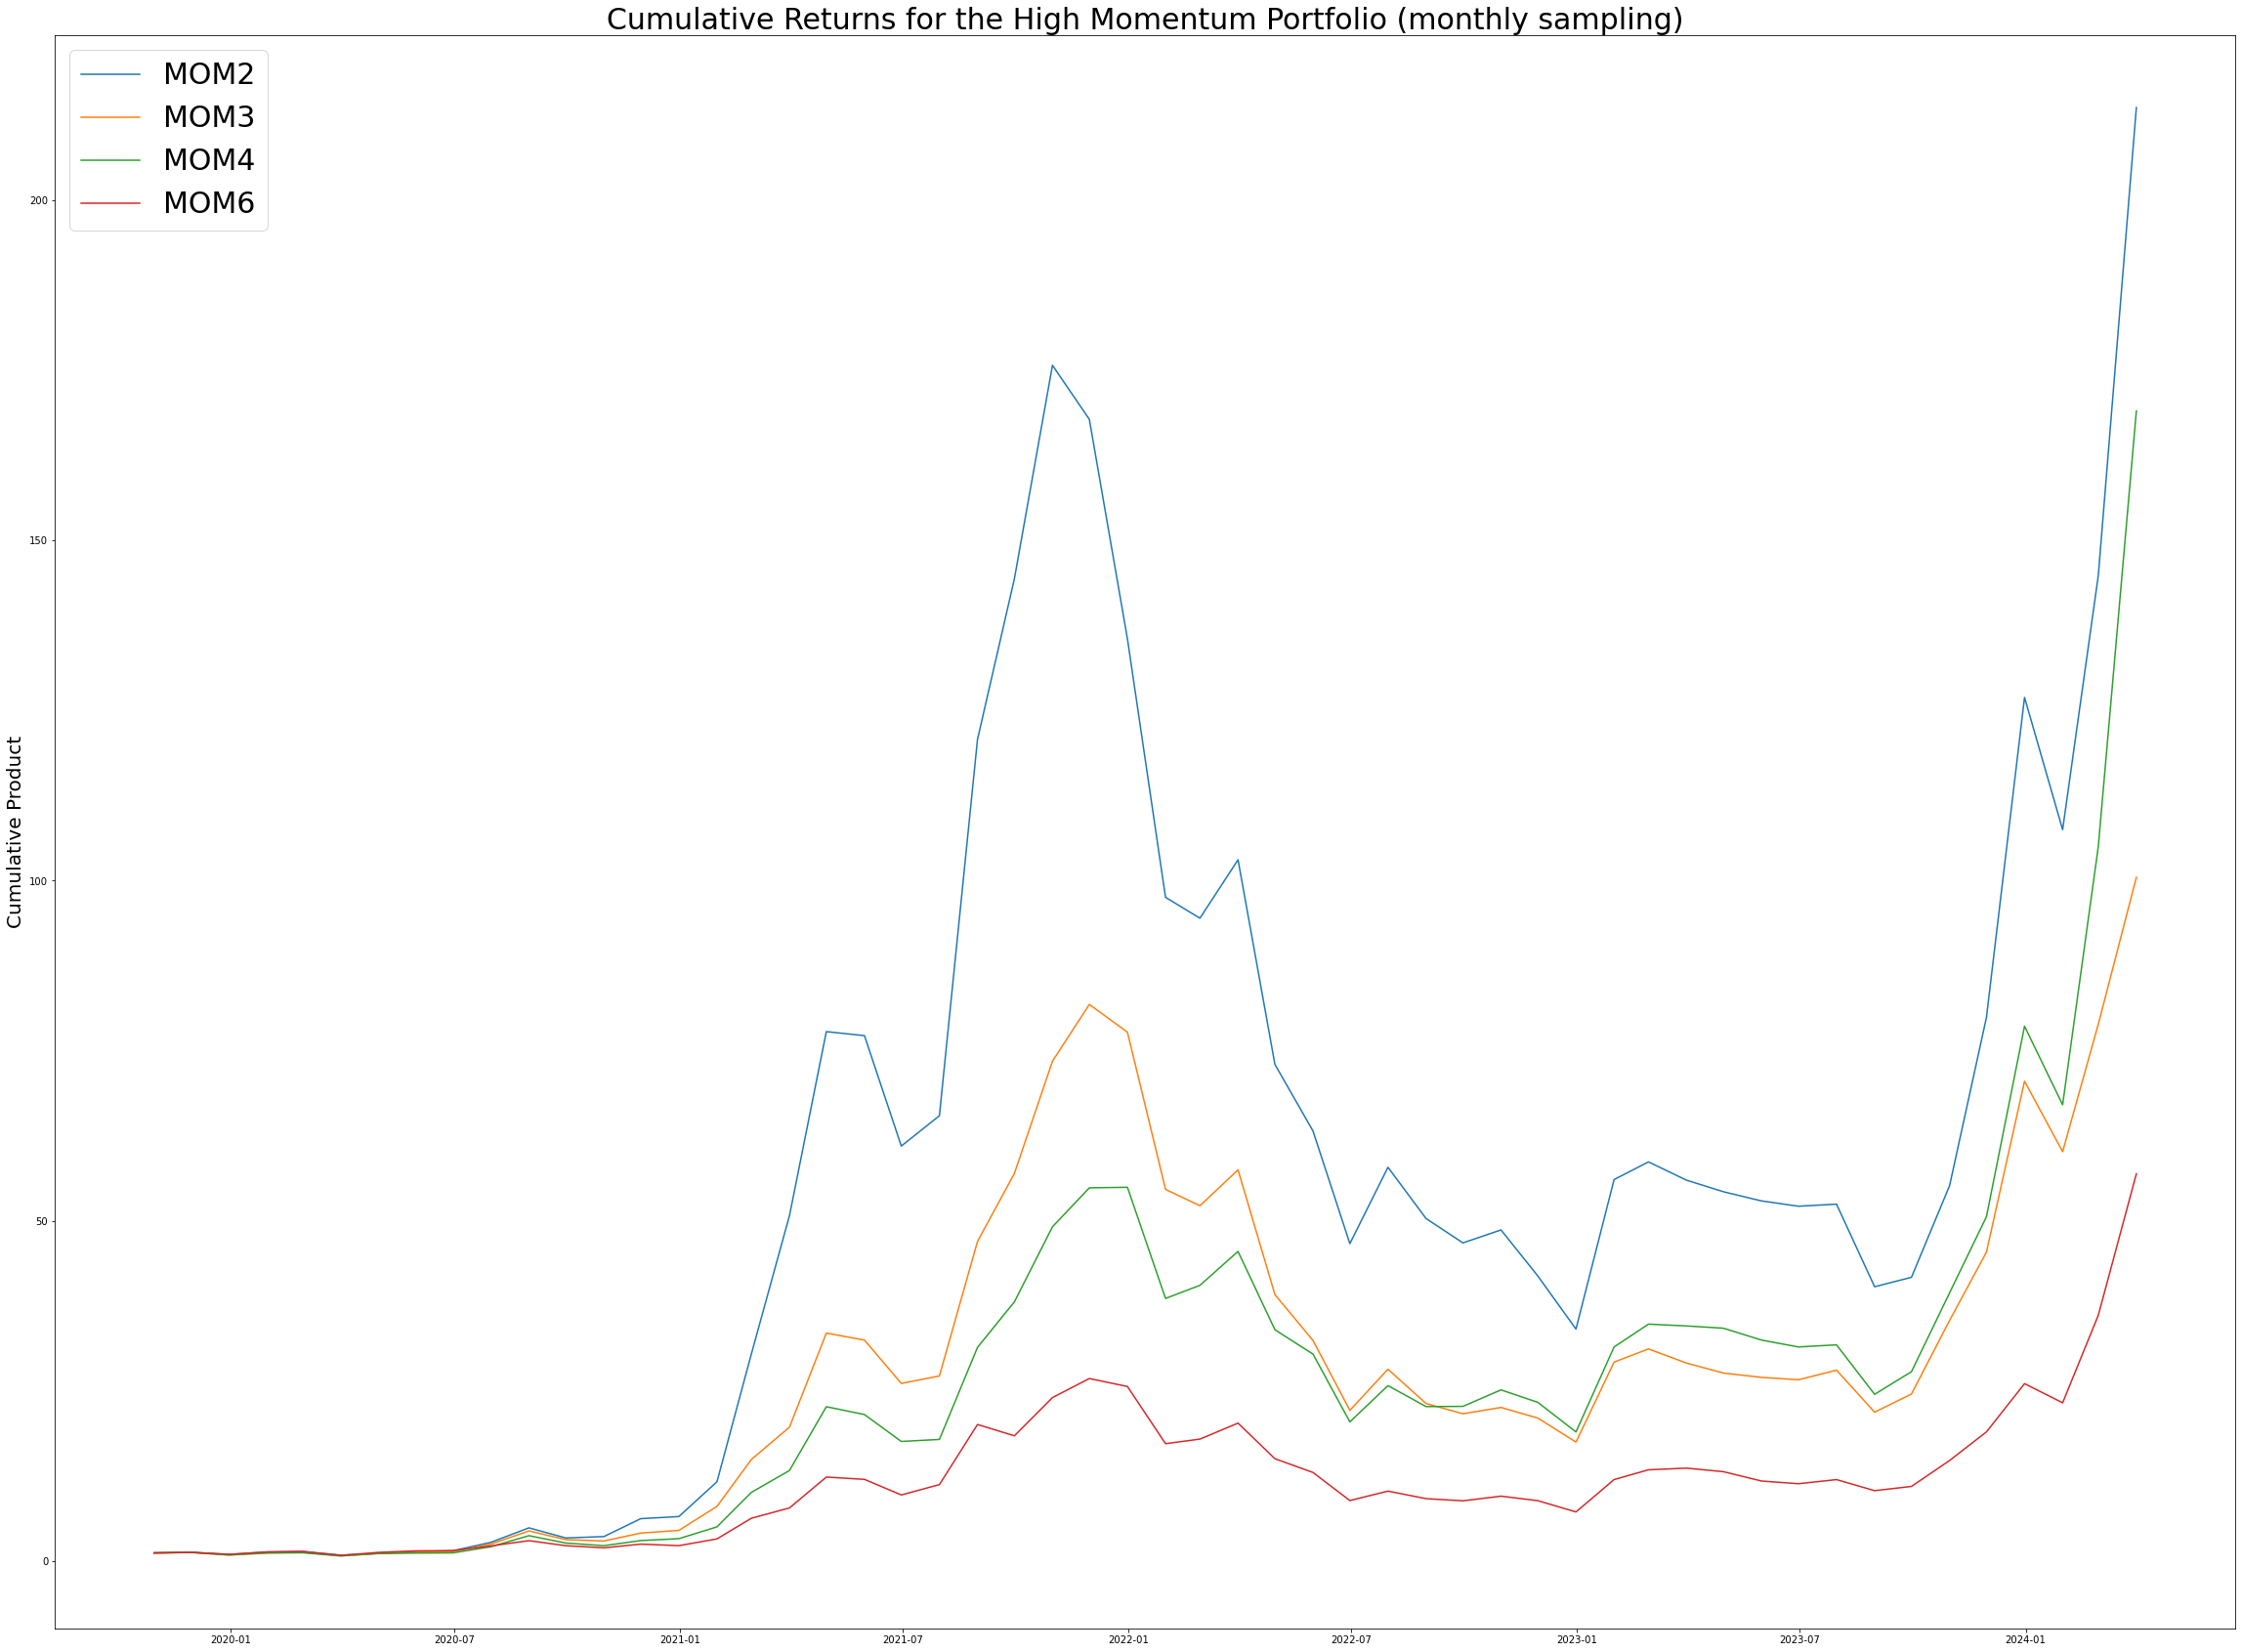

In [13]:
plt.figure(figsize=(40, 30))

for key in list(cprods_monthly.keys()):
    plt.plot(cprods_monthly[key])


plt.ylabel('Cumulative Product', fontsize=20)
plt.title('Cumulative Returns for the High Momentum Portfolio (monthly sampling)', fontsize=30)
plt.legend(["MOM2", "MOM3", "MOM4", "MOM6"], loc='upper left', fontsize=30)
plt.savefig('plot_monthly.png')
plt.show()


In [16]:
#################### GET HOURLY DATA  #################### 

In [17]:
# Define a function that will repetedly call for data until a certain date is reached. Only 2000 rows can be downloaded at a time.

def get_data_h(token):

    data = pd.DataFrame(cryptocompare.get_historical_price_hour(token, "USD", exchange="CCCAGG", toTs=datetime.datetime(2024, 4, 1, 0, 0)))[["close", "time"]]
    data.rename(columns = {'close':token}, inplace = True)
    data.rename(columns = {'time':'Date'}, inplace = True)
    data.set_index("Date", inplace=True)
    data.index = pd.to_datetime(data.index, unit="s")
    
    while True:

        if data.index[0] < datetime.datetime(2023, 1, 1, 0, 0):
            break

        df = pd.DataFrame(cryptocompare.get_historical_price_hour(token, "USD", exchange="CCCAGG", toTs=data.index[0]))[["close", "time"]]
        df.rename(columns = {'close':token}, inplace = True)
        df.rename(columns = {'time':'Date'}, inplace = True)
        df.set_index("Date", inplace=True)
        df.index = pd.to_datetime(df.index, unit="s")

        data = pd.concat([df, data])
        
    return data.loc[data.index >= datetime.datetime(2024, 1, 1, 0, 0), :]

In [18]:
# Download data for BTC separately so that other coins can be added to it in the loop.

main = get_data_h("BTC")

In [27]:
# Add other coins.

for coin in coins:
    if coin == "BTC":
        continue
    else:
        df = get_data_h(coin)
        main = pd.merge(main, df, left_index=True, right_index=True, how='outer')


In [29]:
main.to_excel("hourly.xlsx")

In [ ]:
#################### HOURLY DATA  #################### 

In [14]:
# Import the data.

hourly = pd.read_excel("hourly.xlsx")
hourly.rename(columns = {'Unnamed: 0':'Date'}, inplace = True)
hourly.index = hourly["Date"]
hourly = hourly.drop("Date", axis=1)
hourly = hourly.loc["2024-01-01":]

In [15]:
# Get summary.

hourly.describe().to_excel("summary_hourly.xlsx")

In [16]:
# Get a set of arrays with cumulative products.

cprods_hourly = {}

In [17]:
n = 5
for momentum in [2, 3, 4, 5, 10, 12, 24]:

    # Get a fresh dataset of prices.
    df = hourly.copy()    
    # Remove infnite returns.
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Remove prices equal to zero. This indicates that a coin was not traded, there are no periods where the price was the same for more than one day in the sample.
    df.replace(0, np.nan, inplace=True)
    # Compute momenta and returns.
    for c in coins:
        df[f"{c}_MOM_{momentum}"] = (df[c].shift(1)/df[c].shift(momentum)) - 1
        df[f"{c}_RET"] = (df[c]/df[c].shift(1)) - 1
    # Define new columns.
    df["High Portfolio Return"] = np.nan
    df["Low Portfolio Return"] = np.nan
    df["UMD Portfolio Return"] = np.nan
    # Find portfolios.
    for index, row in df.iterrows():
        if index < datetime.datetime(2024, 1, 2, 0, 0):
            continue
        compare = {}
        for c in df.columns:
            if "_MOM_" not in c:
                continue
            else:
                compare[c.replace(f"_MOM_{momentum}", "_RET")] = row[c]
        
        compare = {k: compare[k] for k in compare if not np.isnan(compare[k])}
        compare = dict(sorted(compare.items(), key=lambda item: item[1], reverse=True))
        
        df.at[index, "High Portfolio Return"] = row[list(compare.keys())[:n]].mean()
        df.at[index, "Low Portfolio Return"] =  row[list(compare.keys())[-n:]].mean()
        df.at[index, "UMD Portfolio Return"] =  row[list(compare.keys())[:n]].mean() - row[list(compare.keys())[-n:]].mean()
    
    # Compute annualized performance metrics of the High Momentum Portfolio.
    annualized_mean_h = df["High Portfolio Return"].mean() * 8760
    annualized_std_h = df["High Portfolio Return"].std() * np.sqrt(8760)
    sharpe_h = annualized_mean_h / annualized_std_h
    # Return results.
    print(f"Results for hourly sampling and momentum look-back of {momentum} hours:")
    print(f"Annualized Average Returns of the High Momentum Portfolio: {annualized_mean_h}.")
    print(f"Annualized standard deviation of the High Momentum Portfolio: {annualized_std_h}.")
    print(f"Sharpe ratio of the High Momentum Portfolio: {sharpe_h}.")
    # Compute annualized performance metrics of the Low Momentum Portfolio.
    annualized_mean_l = df["Low Portfolio Return"].mean() * 8760
    annualized_std_l = df["Low Portfolio Return"].std() * np.sqrt(8760)
    sharpe_l = annualized_mean_l / annualized_std_l
    # Return results.
    print(f"Annualized Average Returns of the Low Momentum Portfolio: {annualized_mean_l}.")
    print(f"Annualized standard deviation of the Low Momentum Portfolio: {annualized_std_l}.")
    print(f"Sharpe ratio of the Low Momentum Portfolio: {sharpe_l}.")
    # Compute annualized performance metrics of the UMD Momentum Portfolio.
    annualized_mean_umd = df["UMD Portfolio Return"].mean() * 8760
    annualized_std_umd = df["UMD Portfolio Return"].std() * np.sqrt(8760)
    sharpe_umd = annualized_mean_umd / annualized_std_umd
    # Return results.
    print(f"Annualized Average Returns of the UMD Momentum Portfolio: {annualized_mean_umd}.")
    print(f"Annualized standard deviation of the UMD Momentum Portfolio: {annualized_std_umd}.")
    print(f"Sharpe ratio of the UMD Momentum Portfolio: {sharpe_umd}.")



    cprods_hourly[momentum] = (1 + df["High Portfolio Return"]).cumprod(skipna=True) 
    
    print("\n")






    

Results for hourly sampling and momentum look-back of 2 hours:
Annualized Average Returns of the High Momentum Portfolio: 1.8138347395319574.
Annualized standard deviation of the High Momentum Portfolio: 0.8033268005264529.
Sharpe ratio of the High Momentum Portfolio: 2.2579039294385264.
Annualized Average Returns of the Low Momentum Portfolio: 2.6990141169246313.
Annualized standard deviation of the Low Momentum Portfolio: 0.7692519822334866.
Sharpe ratio of the Low Momentum Portfolio: 3.508621595082761.
Annualized Average Returns of the UMD Momentum Portfolio: -0.8851793773926747.
Annualized standard deviation of the UMD Momentum Portfolio: 0.5624429241149493.
Sharpe ratio of the UMD Momentum Portfolio: -1.5738119184014592.


Results for hourly sampling and momentum look-back of 3 hours:
Annualized Average Returns of the High Momentum Portfolio: 1.4816077684229567.
Annualized standard deviation of the High Momentum Portfolio: 0.7975612649682228.
Sharpe ratio of the High Momentum Port

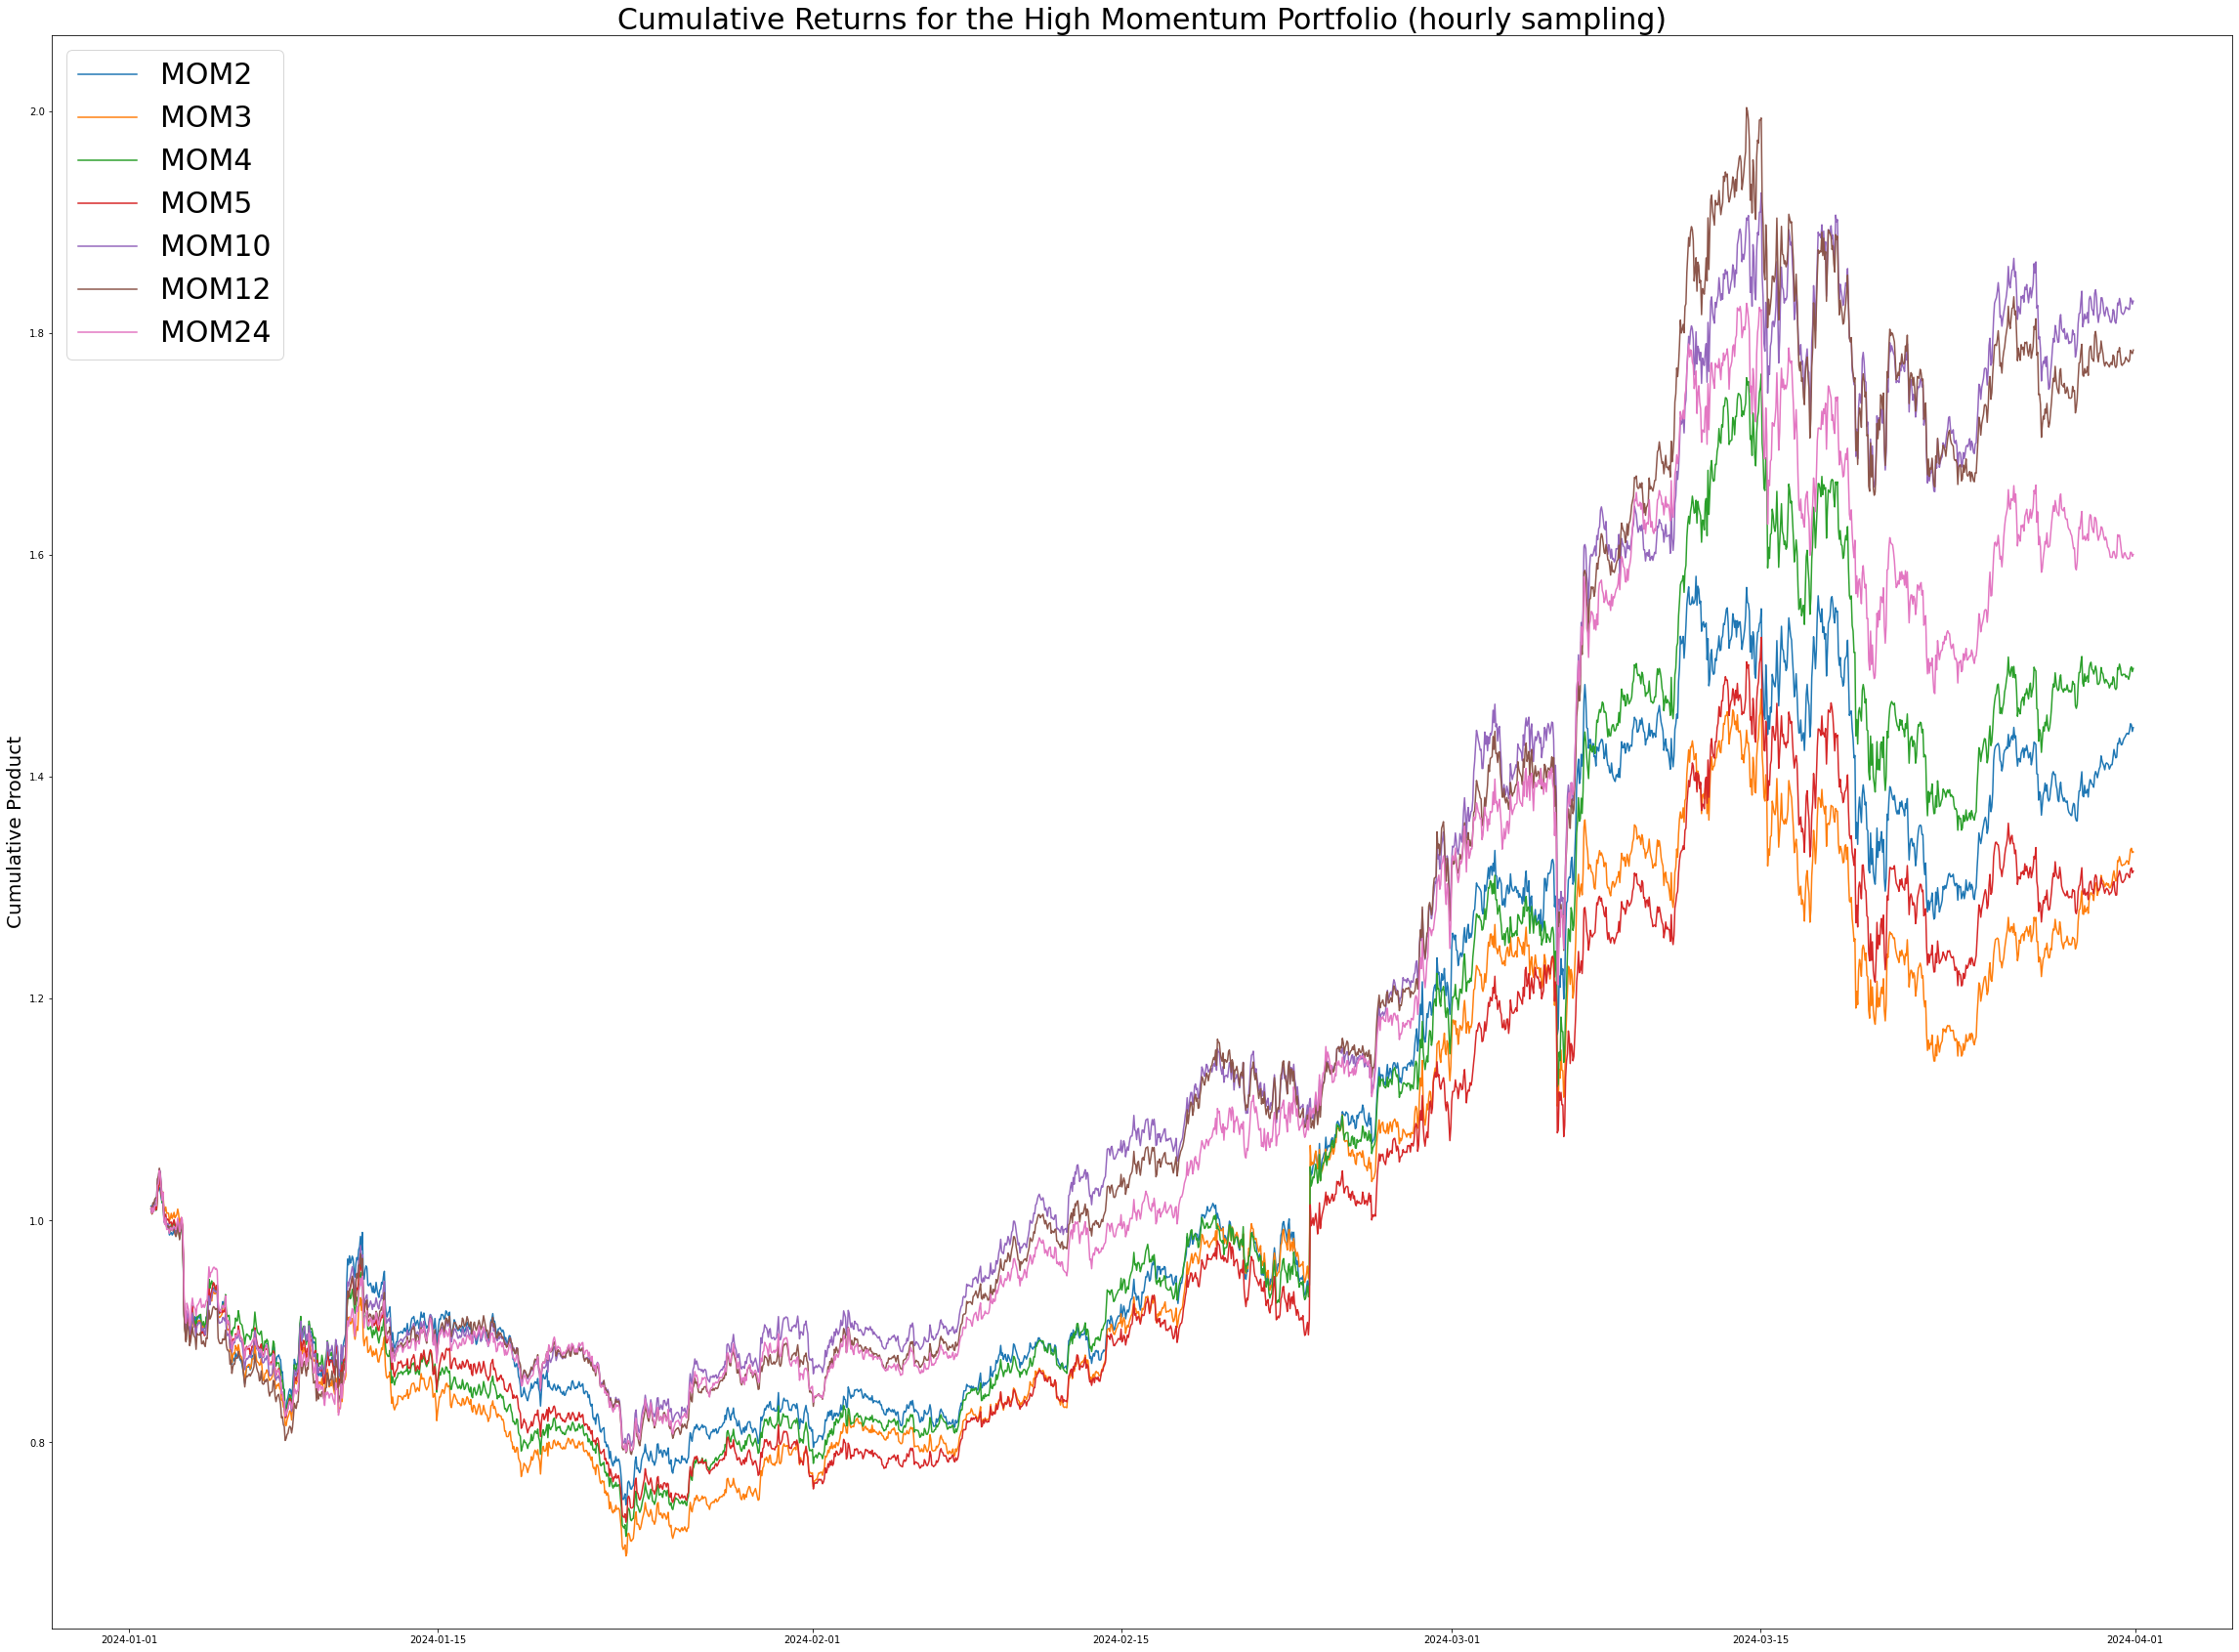

In [18]:
# Plot.

plt.figure(figsize=(40, 30))

for key in list(cprods_hourly.keys()):
    plt.plot(cprods_hourly[key])


plt.ylabel('Cumulative Product', fontsize=20)
plt.title('Cumulative Returns for the High Momentum Portfolio (hourly sampling)', fontsize=30)
plt.legend(["MOM2", "MOM3", "MOM4", "MOM5", "MOM10", "MOM12", "MOM24"], loc='upper left', fontsize=30)
plt.savefig('plot_hourly.png')
plt.show()

In [ ]:
########## COMPARISON #########

In [28]:
# Import data.

comp = pd.read_excel("check.xlsx")
comp.rename(columns = {'Unnamed: 0':'Date'}, inplace = True)
comp = comp[["BTC", "ETH", "Date"]]
comp.index = comp["Date"]
comp = comp.drop("Date", axis=1)
comp = comp.loc["2019-04-30":]
for c in comp.columns:
    comp[f"{c}_RET"] = comp[c]/comp[c].shift(1) - 1

In [35]:
# Compute returns and ratios.

btc_annualized_returns = comp["BTC_RET"].mean() * 365
btc_annualized_std = comp["BTC_RET"].std() * np.sqrt(365)

btc_sharpe = btc_annualized_returns / btc_annualized_std 

eth_annualized_returns = comp["ETH_RET"].mean() * 365
eth_annualized_std = comp["ETH_RET"].std() * np.sqrt(365)

eth_sharpe = eth_annualized_returns / eth_annualized_std

In [32]:
# Compute returns of a equally weighted portfolio.

comp["fifty"] = comp["BTC_RET"] * 0.5 + comp["ETH_RET"] * 0.5

In [36]:
# Compute returns and ratios for the equally weighted portfolio.

fifty_annualized_returns = comp["fifty"].mean() * 365
fifty_annualized_std = comp["fifty"].std() * np.sqrt(365)
fifty_sharpe = fifty_annualized_returns / fifty_annualized_std

In [37]:
# Print results.

print(f"Annualized Returns of BTC in the same sample period: {btc_annualized_returns}.")
print(f"Annualized Standard Deviation of BTC in the same sample period: {btc_annualized_std}.")
print(f"Sharpe ratio of BTC in the same sample period: {btc_sharpe}.")

print(f"Annualized Returns of ETH in the same sample period: {eth_annualized_returns}.")
print(f"Annualized Standard Deviation of ETH in the same sample period: {eth_annualized_std}.")
print(f"Sharpe ratio of ETH in the same sample period: {eth_sharpe}.")

print(f"Annualized Returns of ETH/BTC (50/50) in the same sample period: {fifty_annualized_returns}.")
print(f"Annualized Standard Deviation of ETH/BTC (50/50) in the same sample period: {fifty_annualized_std}.")
print(f"Sharpe ratio of ETH/BTC (50/50) in the same sample period: {fifty_sharpe}.")

Annualized Returns of BTC in the same sample period: 0.7654660218677334.
Annualized Standard Deviation of BTC in the same sample period: 0.6852896811929238.
Sharpe ratio of BTC in the same sample period: 1.1169962759912595.
Annualized Returns of ETH in the same sample period: 1.0121603441301124.
Annualized Standard Deviation of ETH in the same sample period: 0.8625675980447967.
Sharpe ratio of ETH in the same sample period: 1.1734272727429147.
Annualized Returns of ETH/BTC (50/50) in the same sample period: 0.8888131829989226.
Annualized Standard Deviation of ETH/BTC (50/50) in the same sample period: 0.7384258052591595.
Sharpe ratio of ETH/BTC (50/50) in the same sample period: 1.2036594288399536.
